In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats

# ----------------------------
# Nature-like style (single place)
# ----------------------------
BASE_FONTSIZE = 8
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": BASE_FONTSIZE,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    "axes.labelsize": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.linewidth": 0.8,
    "axes.spines.right": False,
    "axes.spines.top": False,

    "xtick.labelsize": BASE_FONTSIZE,
    "ytick.labelsize": BASE_FONTSIZE,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 0,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "lines.linewidth": 1.0,
    "lines.markersize": 3.5,

    "figure.dpi": 300,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})



Matplotlib is building the font cache; this may take a moment.


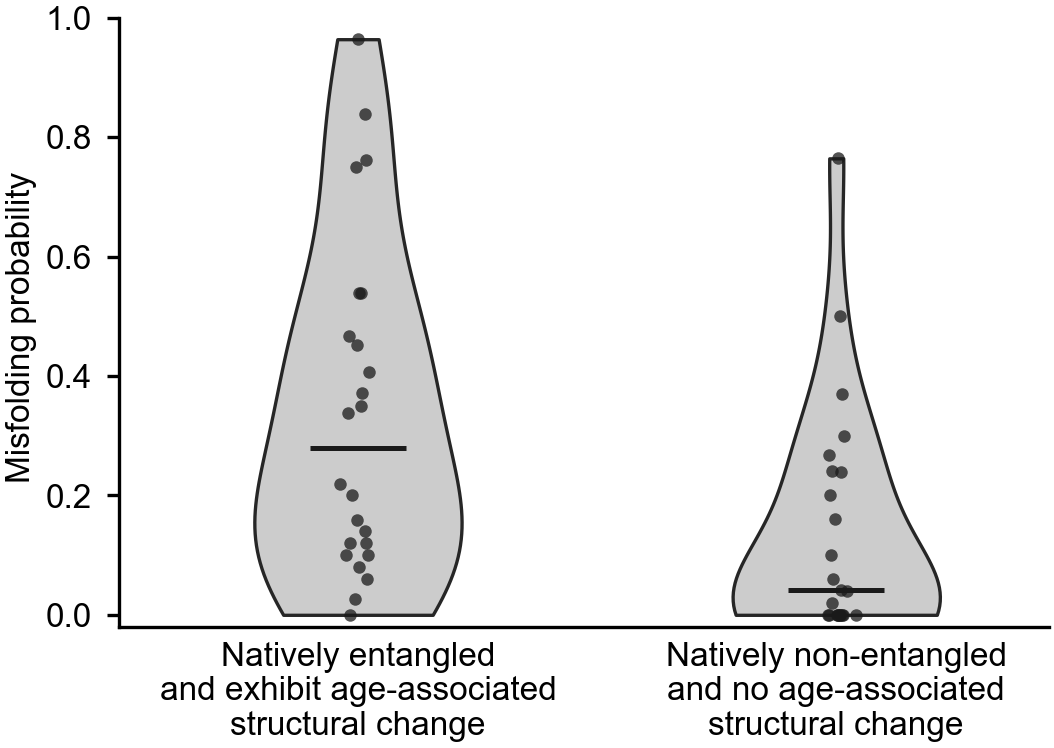

In [2]:
misfolding_sc_ent = np.array([0.5389762863937464, 0.3380882518903058, 0.13982745686421605, 0.060053277304618624, 0.21969992498124535, 0.09999999999999998, 0.08021711548712096, 0.027279084261891406, 0.9640966938253316, 7.501875468829411e-06, 0.12027756939234813, 0.8391394399975083, 0.538316116399973, 0.0999932482614273, 0.3721645252299388, 0.12027006751687919, 0.3490699426810373, 0.4675571801409478, 0.7611552697045082, 0.45231057764441107, 0.7493455497382199, 0.20001500375093773, 0.40721497248990934, 0.15801950487621907])
misfolding_nsc_nent = np.array([0.24049168257021358, 0.06000360111634606, 0.04192581813630003, 7.613362974723259e-06, 0.5008899001960033, 0.0, 0.0, 0.020000000000000018, 0.09997749437359338, 0.2682745686421606, 0.0, 0.04013894828452891, 0.16000000000000003, 0.0, 0.0, 0.37007135514754985, 0.0, 0.23982745686421603, 0.20101275318829703, 2.4589559273091588e-05, 0.0, 0.0, 0.29968492123030754, 0.7645290758323167])


data = [misfolding_sc_ent, misfolding_nsc_nent]
labels = [
    "Natively entangled\nand exhibit age-associated\nstructural change",
    "Natively non-entangled\nand no age-associated\nstructural change"
]

positions = np.array([0.9, 2.7])



# ----------------------------
# Plot (single-column width)
# ----------------------------
fig, ax = plt.subplots(figsize=(4.0, 3.5))  # single column width

vp = ax.violinplot(
    data, positions=positions, widths=0.78,
    showmeans=False, showmedians=False, showextrema=False
)

# Grayscale styling (Nature friendly)
for body in vp["bodies"]:
    body.set_facecolor("0.80")    # light gray
    body.set_edgecolor("0.15")    # dark edge
    body.set_linewidth(0.8)
    body.set_alpha(1.0)

# Median lines
for x, d in zip(positions, data):
    med = np.percentile(d, 50)
    ax.plot([x - 0.18, x + 0.18], [med, med], lw=1.2, color="0.10", solid_capstyle="butt")

# Jittered points
rng = np.random.default_rng(42)
for x, d in zip(positions, data):
    jitter = rng.normal(0, 0.035, size=len(d))
    ax.plot(np.full(len(d), x) + jitter, d, "o",
            ms=3.0, alpha=0.75, mec="none", mfc="0.10")

# Labels and ticks
ax.set_ylabel("Misfolding probability ", labelpad=2)
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=0, ha="center", linespacing=1.15)
ax.set_xlim(0.0, 3.5)

# Y range and ticks (adjust if you want a tighter top)
ax.set_ylim(-0.02, 1.00)
ax.set_yticks(np.arange(0.0, 1.01, 0.2))
ax.tick_params(top=False, right=False)

plt.subplots_adjust(bottom=0.30)

# Save both vector and raster
fig.savefig("Nature_style_misfolding_propensity_violin.pdf")          # vector for Nature
fig.savefig("Nature_style_misfolding_propensity_violin.png", dpi=600) # raster preview

plt.show()